# Segmentación de clientes mediante clustering

En este notebook se aplican técnicas de aprendizaje no supervisado para segmentar clientes según sus características.

En primer lugar se determina un número adecuado de clusters utilizando métricas de evaluación. Posteriormente se aplica el algoritmo K-Means, se visualizan los resultados mediante reducción de dimensionalidad y finalmente se interpretan los grupos obtenidos.

In [28]:
import numpy as np
import pandas as pd
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.style.use("default")
sns.set_theme(style="whitegrid")

## Carga del conjunto de datos procesado

In [29]:
df = pd.read_csv("../datos/mall_customers_processed.csv")

df.head()

,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,-1.424569,-1.738999,-0.434801,1.128152
1,-1.281035,-1.738999,1.195704,1.128152
2,-1.352802,-1.700830,-1.715913,-0.886405
3,-1.137502,-1.700830,1.040418,-0.886405
4,-0.563369,-1.662660,-0.395980,-0.886405


---
## Selección del número de clusters

Como K-Means requiere especificar el número de clusters antes del entrenamiento, se utilizan dos criterios para seleccionar un valor adecuado:

- Método del codo.
- Coeficiente de silueta.

La elección final se basa en el análisis conjunto de ambas métricas.

In [30]:
inertia = []

K = range(2, 11)

for k in K:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(df)

    inertia.append(model.inertia_)

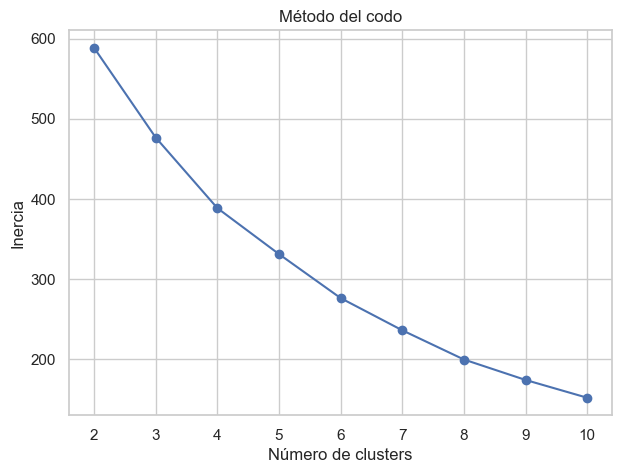

In [31]:
plt.figure(figsize=(7,5))

plt.plot(K, inertia, marker="o")

plt.xlabel("Número de clusters")
plt.ylabel("Inercia")

plt.title("Método del codo")

plt.show()

In [32]:
silhouette = []

for k in K:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(df)

    silhouette.append(silhouette_score(df, labels))

print(silhouette)

[np.float64(0.2518152915788437), np.float64(0.25951265087431563), np.float64(0.2983972818544038), np.float64(0.3040600988258827), np.float64(0.33107393337175933), np.float64(0.3573771582429211), np.float64(0.3879927454351689), np.float64(0.4030916511655521), np.float64(0.42076374869477745)]


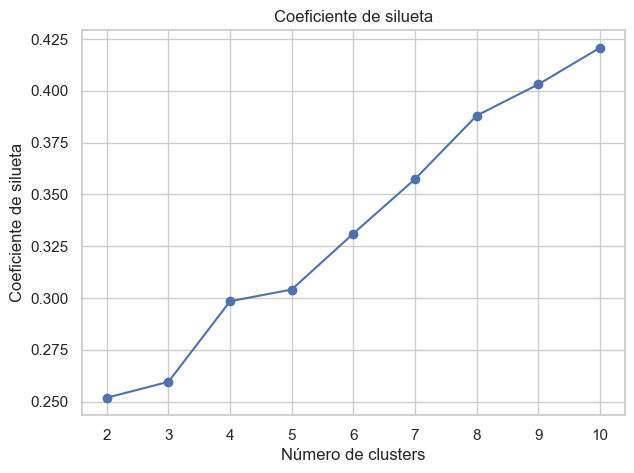

In [33]:
plt.figure(figsize=(7,5))

plt.plot(K, silhouette, marker="o")

plt.xlabel("Número de clusters")
plt.ylabel("Coeficiente de silueta")

plt.title("Coeficiente de silueta")

plt.show()

### Selección del valor de \(k\)

A partir del método del codo y del coeficiente de silueta se selecciona el número de clusters que ofrece el mejor compromiso entre compacidad y separación de los grupos. 

El método del codo no muestra una gran amortiguación para ningún valor de k. Por otro lado, se ve un gran planchamiento en k=4. Luego se elige el valor k=4.

---
## Aplicación de K-Means

Una vez seleccionado el número de clusters, se entrena el modelo K-Means sobre el conjunto de datos preprocesado y se asigna cada cliente al grupo correspondiente.

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(df)

df["Cluster"] = clusters

df.head()

,Age,Annual Income (k$),Spending Score (1-100),Gender_Male,Cluster
0,-1.424569,-1.738999,-0.434801,1.128152,1
1,-1.281035,-1.738999,1.195704,1.128152,1
2,-1.352802,-1.700830,-1.715913,-0.886405,0
3,-1.137502,-1.700830,1.040418,-0.886405,2
4,-0.563369,-1.662660,-0.395980,-0.886405,0


## Distribución de observaciones por cluster

Se analiza la cantidad de clientes asignados a cada grupo para verificar que la partición obtenida sea razonable.

In [43]:
cluster_counts = df["Cluster"].value_counts().sort_index()

cluster_counts

Cluster
0    56
1    46
2    56
3    42
Name: count, dtype: int64

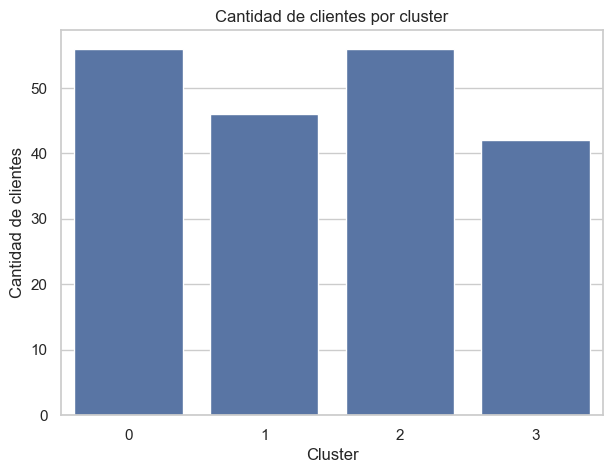

In [44]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Cluster",
    order=sorted(df["Cluster"].unique())
)

plt.title("Cantidad de clientes por cluster")
plt.xlabel("Cluster")
plt.ylabel("Cantidad de clientes")

plt.show()

---
## Visualización mediante PCA

Como el conjunto de datos posee cuatro variables, se aplica Análisis de Componentes Principales (PCA) para proyectar la información en dos dimensiones y facilitar la visualización de los clusters obtenidos.

In [46]:
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(
    df.drop(columns="Cluster")
)

In [47]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = df["Cluster"]

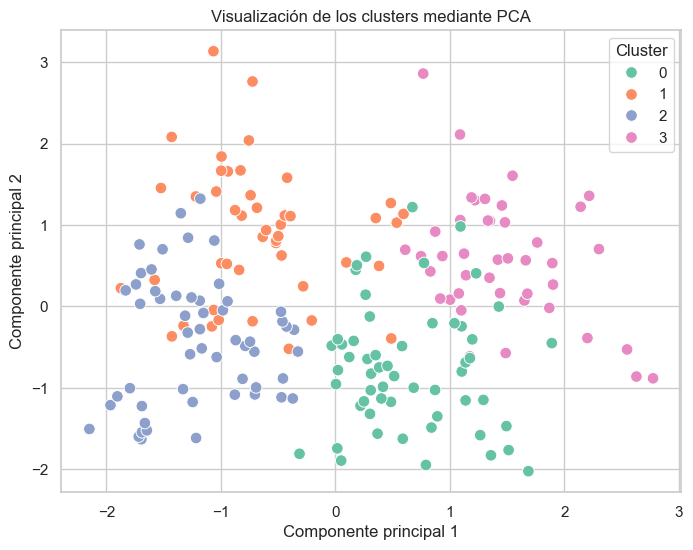

In [48]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=70
)

plt.title("Visualización de los clusters mediante PCA")

plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")

plt.legend(title="Cluster")

plt.show()

In [49]:
explained = pca.explained_variance_ratio_

print(f"Varianza explicada por PC1: {explained[0]:.2%}")
print(f"Varianza explicada por PC2: {explained[1]:.2%}")
print(f"Varianza total explicada: {explained.sum():.2%}")

Varianza explicada por PC1: 33.69%
Varianza explicada por PC2: 26.23%
Varianza total explicada: 59.92%


---
## Exportación de resultados

Se almacena el conjunto de datos procesado junto con la etiqueta del cluster asignado a cada observación. Este archivo será utilizado posteriormente para interpretar las características de cada grupo utilizando las variables en su escala original.

In [51]:
df.to_csv(
    "../datos/mall_customers_clustered.csv",
    index=False
)

---
## Conclusiones

Se aplicó el algoritmo K-Means sobre el conjunto de datos previamente procesado, seleccionando cuatro clusters a partir del análisis conjunto del método del codo y del coeficiente de silueta.

La proyección mediante PCA permitió obtener una representación bidimensional de los grupos identificados, facilitando una primera inspección visual de la segmentación obtenida.

En el siguiente notebook se analizarán las características de cada cluster utilizando las variables originales del conjunto de datos, con el objetivo de interpretar el perfil de los distintos segmentos de clientes.